In [17]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [18]:
widthS = 5
widthP = 10
X, Y = widthS+widthP, 200
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 0.0 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[:widthS:] = muS
mu[widthS:] = muP

V0 = 5 * t
V = np.zeros(lattice.X)
V[:widthS] = V0
V[widthS-1] = V0/2

V_prime0 = 1.5 * t
V_prime = np.zeros(lattice.X)
V_prime[widthS:] = V_prime0
V_prime[widthS-1] = V_prime0/2

U = None

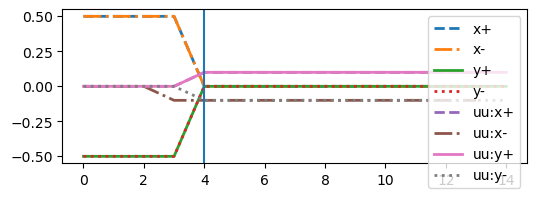

In [19]:
H = Hamiltonian(
    t, mu, lattice,
    U=U, V_prime=V_prime, g_s=V,
    F_init=[0.5, 0.5, -0.5, -0.5],
    Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
    Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
)

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.real(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.real(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="uu:x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="uu:x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="uu:y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="uu:y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthS-1)

In [24]:
bdg_sc(H, maxiter=1000, temperature=T, rtol=1e-3, atol=1e-6)
F, Fuu, Fdd = H.get_correlations()

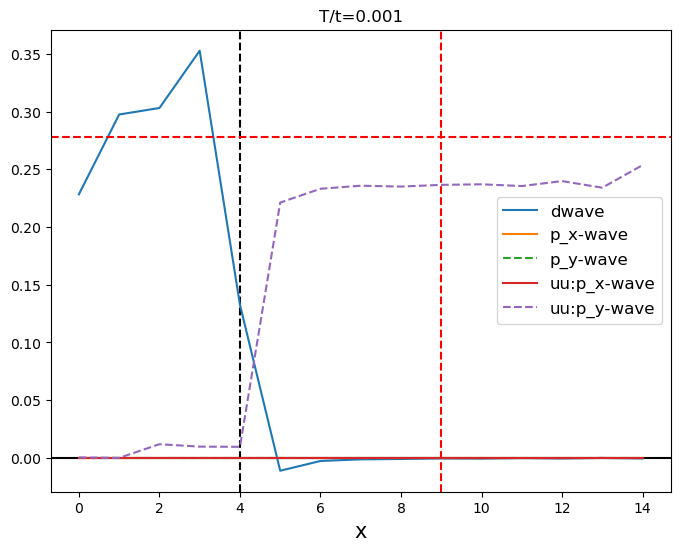

(8.592037264735089e-09+1.3564917155023606e-10j)


In [25]:
x = np.arange(0, widthS + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}")
axs.axhline(0, color = 'black')
axs.axvline(widthS-1, color='black', linestyle='--')
axs.axvline(x[int(widthS+widthP/2)-1], color='red', linestyle='--')

axs.plot(x, np.real(F.dwave), label="dwave")
axs.plot(x, np.real(F.px), label="p_x-wave")
axs.plot(x, np.imag(F.py), "--", label="p_y-wave")
axs.plot(x, np.real(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.imag(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.axhline(0.278, linestyle='--', color="red")
# axs.set_xlim(20, 45)
# axs.set_ylim(0, 0.3)
axs.legend(fontsize=12, loc="best")
plt.show()

print(Fuu.px[int(widthS+widthP/2)-1])